### 1.研究不同reduce oreder model. 1.1 实现，静态凝聚、动态凝聚
### 2.提供了静态凝聚、动态凝聚和SEREP三种降维手段。

In [128]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP
import DM_Method as DM_M

### 此处高度集成了SEREP方法，可以从代码库中直接调用，添加了网格3*3的选项。

In [129]:
# # Example call to the function
num_nodes = 793
node_position_params = (424, 6, 10)
hydrodynamic_data_path = "E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_120_direction0.nc"
structure_data_paths = {
    'mass': 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_MASS1.mtx',
    'stiffness': 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_STIF1.mtx'}

# 3x3
# num_nodes = 2121
# node_position_params = (1106,10,10)
# hydrodynamic_data_path = "E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_145_direction0.nc"
# structure_data_paths = {
#     'mass': 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh3_3_MASS1.mtx',
#     'stiffness': 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh3_3_STIF1.mtx'}


In [130]:
result_serep = DM_M.perform_RODM_reduce_order_model(num_nodes, node_position_params, hydrodynamic_data_path, structure_data_paths,use_hydrostatic=True)

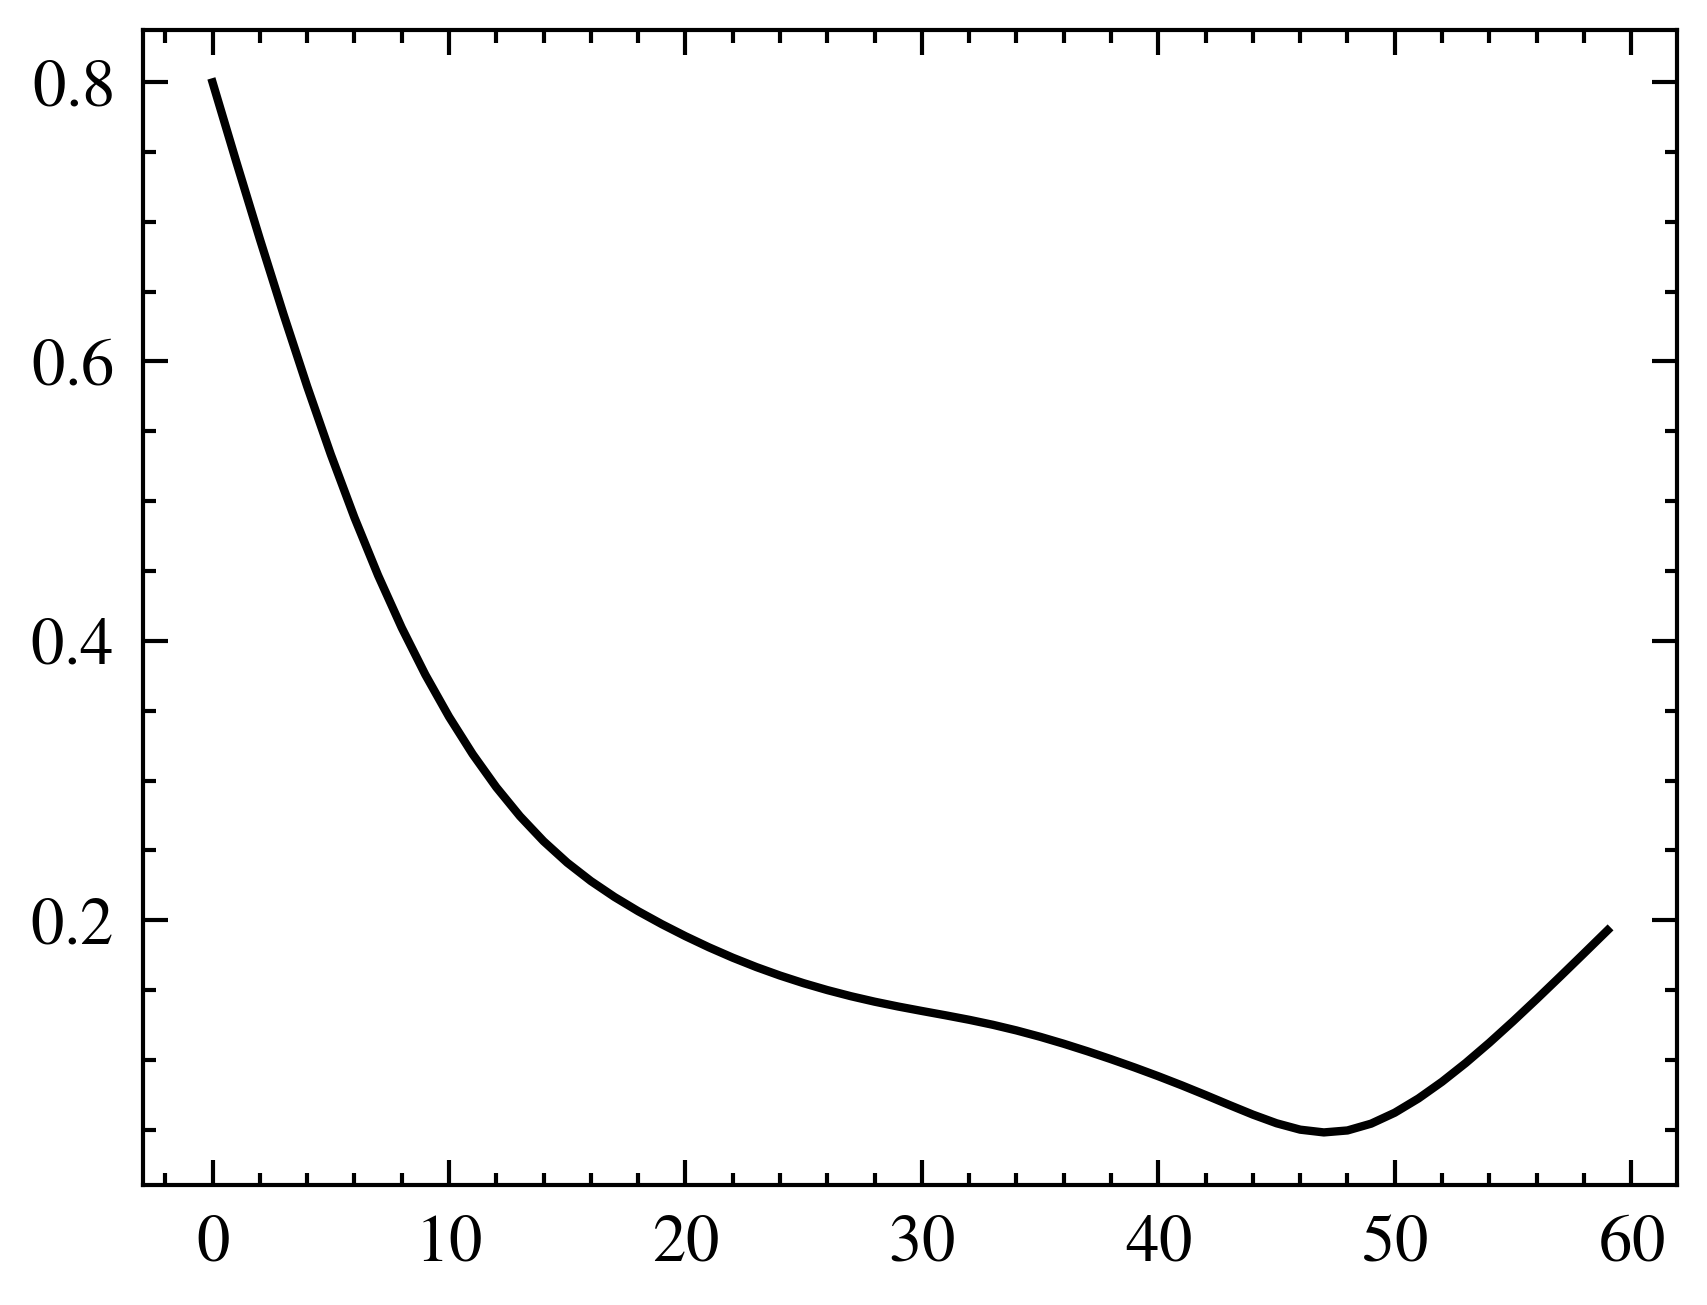

In [131]:
import matplotlib.pyplot as plt
mid = result_serep[367*5-5:427*5-5,:]
heave = abs(mid[2::5])
plt.plot(heave) 
# 与实验结果进行对比、绘图
# from DM_Verify import process_exp_data
# x, y = process_exp_data("E:\phd\Code\DM-FEM2D\data\Experiment_300_60\exp_120.txt")
# y = np.array(y)
# # 绘图
# import scienceplots
# x1 = np.linspace(0,1,60)
# plt.style.use(['science','no-latex','ieee'])
# plt.plot(x1,abs(mid[2::5][::-1]), label="Present")
# plt.scatter(x,y,color = 'red',label="Model test",s=10)
# plt.legend() 
# plt.ylim(0,1.2) # 调整y轴坐标
# plt.xlabel(r'$x/L$',)
# plt.ylabel(r'Heave RAO ($m$/$m$)')

In [132]:
def static_condensation(K, M, master_dofs, slave_dofs):
    """
    Perform static condensation on a stiffness matrix and create a transformation matrix.
    
    Parameters:
    K (np.array): The full stiffness matrix.
    master_dofs (list): Indices of the master (primary) degrees of freedom.
    slave_dofs (list): Indices of the slave (secondary) degrees of freedom.
    
    Returns:
    np.array: The reduced stiffness matrix for the master DOFs.
    np.array: The transformation matrix to recover the full DOFs from the reduced DOFs.
    """
    # Extract submatrices
    K_mm = K[np.ix_(master_dofs, master_dofs)]
    K_ms = K[np.ix_(master_dofs, slave_dofs)]
    K_sm = K[np.ix_(slave_dofs, master_dofs)]
    K_ss = K[np.ix_(slave_dofs, slave_dofs)]
    # print(K_mm.shape, K_ms.shape, K_sm.shape, K_ss.shape)
    # Perform static condensation
    K_reduced = K_mm - np.dot(np.dot(K_ms, np.linalg.inv(K_ss)), K_sm)

    # # Create the transformation matrix
    T_ms = -np.dot(np.linalg.inv(K_ss), K_sm)
    T_mm = np.eye(len(master_dofs))
    T = np.vstack((T_mm, T_ms))
    M_reduced = T.T@M@T
    # K_reduced = T.T@K@T

    return M_reduced,K_reduced,T

# def dynamic_condensation(K, M, master_dofs, slave_dofs):
#     """
#     Perform dynamic condensation on a system and create a transformation matrix.

#     Parameters:
#     M (np.array): The mass matrix.
#     K (np.array): The stiffness matrix.
#     master_dofs (list): Indices of the master degrees of freedom.
#     slave_dofs (list): Indices of the slave degrees of freedom.

#     Returns:
#     np.array: The reduced mass matrix.
#     np.array: The reduced stiffness matrix.
#     np.array: The transformation matrix to recover the full DOFs from the reduced DOFs.
#     """
#     # Extract submatrices
#     M_mm = M[np.ix_(master_dofs, master_dofs)]
#     M_ms = M[np.ix_(master_dofs, slave_dofs)]
#     M_sm = M[np.ix_(slave_dofs, master_dofs)]
#     M_ss = M[np.ix_(slave_dofs, slave_dofs)]
    
#     K_mm = K[np.ix_(master_dofs, master_dofs)]
#     K_ms = K[np.ix_(master_dofs, slave_dofs)]
#     K_sm = K[np.ix_(slave_dofs, master_dofs)]
#     K_ss = K[np.ix_(slave_dofs, slave_dofs)]

#     # # Perform dynamic condensation
#     M_reduced = M_mm - np.dot(np.dot(M_ms, np.linalg.inv(M_ss)), M_sm)
#     K_reduced = K_mm - np.dot(np.dot(K_ms, np.linalg.inv(K_ss)), K_sm)

#     # Create the transformation matrix
#     T_ms = -np.dot(np.linalg.inv(K_ss), K_sm)
#     T_mm = np.eye(len(master_dofs))

#     # Stack to form the full transformation matrix
#     T = np.vstack((T_mm, T_ms))
#     # M_reduced = T.T@M@T
#     # K_reduced = T.T@K@T
#     return M_reduced, K_reduced, T



def dynamic_condensation(K, M, master_dofs, slave_dofs, omega):
    """
    Perform *true* dynamic condensation on a system for a given single frequency omega,
    and create a frequency-dependent transformation matrix T(omega).

    Parameters:
    -----------
    K (np.array): The full stiffness matrix of shape (n, n).
    M (np.array): The full mass matrix of shape (n, n).
    master_dofs (list): Indices of the master degrees of freedom (kept DOFs).
    slave_dofs (list): Indices of the slave degrees of freedom (eliminated DOFs).
    omega (float): The reference frequency (rad/s) for the dynamic condensation.

    Returns:
    --------
    M_reduced (np.array): The reduced mass matrix in the master DOFs subspace.
    K_reduced (np.array): The reduced stiffness matrix in the master DOFs subspace.
    T_omega (np.array):  The transformation matrix T(omega),
                         dimension = [n, len(master_dofs)].
    """

    # 1. Extract submatrices
    K_mm = K[np.ix_(master_dofs, master_dofs)]
    K_ms = K[np.ix_(master_dofs, slave_dofs)]
    K_sm = K[np.ix_(slave_dofs, master_dofs)]
    K_ss = K[np.ix_(slave_dofs, slave_dofs)]

    M_mm = M[np.ix_(master_dofs, master_dofs)]
    M_ms = M[np.ix_(master_dofs, slave_dofs)]
    M_sm = M[np.ix_(slave_dofs, master_dofs)]
    M_ss = M[np.ix_(slave_dofs, slave_dofs)]

    # 2. Compute the frequency-dependent inverse block
    #    (K_ss - omega^2 M_ss)^(-1)
    # 需要保证 (K_ss - omega^2 M_ss) 非奇异（即不可逆），
    # 否则在这频率下会出现局部刚度与质量耦合的奇异情况。
    K_dyn_inv = np.linalg.pinv(K_ss - (omega**2)*M_ss)

    # 3. Construct T_ms(omega)
    #    T_ms = - [ (K_ss - omega^2 M_ss)^(-1) (omega^2 M_sm - K_sm ) ]
    T_ms = - K_dyn_inv @ ((omega**2)*M_sm - K_sm)

    # 4. Stack to form the full transformation matrix T(omega)
    #    T(omega) = [ I
    #                 T_ms ]
    T_mm = np.eye(len(master_dofs))
    T_omega = np.vstack((T_mm, T_ms))

    # 5. Compute the reduced mass and stiffness matrices
    #    M^*(omega) = T(omega)^T M T(omega)
    #    K^*(omega) = T(omega)^T K T(omega)
    M_reduced = T_omega.T @ M @ T_omega
    K_reduced = T_omega.T @ K @ T_omega   # <-- 这里要改成这样

    return M_reduced, K_reduced, T_omega


In [133]:
# define parameters
num_nodes = 793 # 63 793
master_nodes = DM_A.calculate_node_positions(424,6,10) #[41, 39, 37, 35, 33, 31, 29, 27, 25, 23] DM_A.calculate_node_positions(424,6,10)
dataset = merge_complex_values(xr.open_dataset(hydrodynamic_data_path))

# read mass and stiffness matrix
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_MASS1.mtx'#'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_STIF1.mtx' #'E:\phd\Code\DM-FEM2D\StructureData\JobMesh5_5_STIF1.mtx' 
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

# reduce dofs
M_consistant= SEREP.reduce_dofs(M, num_nodes, [5])
k = SEREP.reduce_dofs(k, num_nodes, [5])

# transform mass matrix, beta=0 is consistant mass matrix
M = SEREP.transform_mass_matrix(M_consistant,beta=0)
# obtaine master dofs and slave dofs
MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)

# reduce matrix use SEREP
MR,KR,T = SEREP.SEREP(k, M, SlaveDofs, master_nodes)
MR_static, KR_static,T_static = static_condensation(k, M, MasterDofs, SlaveDofs)
MR_dynamic, KR_dynamic, T_dynamic = dynamic_condensation(k, M, MasterDofs, SlaveDofs, 1)


In [134]:
def couple_equation(dataset, MR, KR, T, master_nodes, MasterDofs, SlaveDofs):
    # read hydrodynamic data
    omega = dataset.omega.values
    added_mass = dataset['added_mass'][0].values
    radiation_damping = dataset['radiation_damping'][0].values
    inertia_matrix = dataset['inertia_matrix'].values
    # hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    F_w = dataset['Froude_Krylov_force'][0].values + dataset['diffraction_force'][0].values
    # REDUCE THE MATRICES
    added_mass = SEREP.reduce_dofs(added_mass,10,[5])
    radiation_damping = SEREP.reduce_dofs(radiation_damping,10,[5])
    # hyrostatic stiffness or fem spring stiffness
    # 1. choice hydrostatic stiffness
    hydrostatic_stiffness = dataset['hydrostatic_stiffness'].values
    hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,10,[5])
    # 2. choice fem spring stiffness
    # hydrostatic_stiffness = SEREP.get_fem_spring_stiffness(num_nodes, nodes_per_row, Area)
    # hydrostatic_stiffness = SEREP.reduce_dofs(hydrostatic_stiffness,num_nodes,[5])
    # hydrostatic_stiffness = T.T @ hydrostatic_stiffness @ T

    inertia_matrix = SEREP.reduce_dofs(inertia_matrix,10,[5])
    F_w = SEREP.reduce_force_matrix_dofs(F_w, 10, 5).reshape(1,50)
    # F_w = F_w.reshape(10,5)[::-1].reshape(1,50)
    # Generate the system matrices
    mass = added_mass + MR
    damping = radiation_damping
    stiffness =  hydrostatic_stiffness + KR
    # Solve in frequency domain
    master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, F_w, omega)
    # Restore global displacement under disorder masterdofs and slavedofs
    global_displacement_disorder = T @ master_displacement

    master_displacement = master_displacement.reshape(10,5)[::-1].reshape(50,1)
    # # Reorder global displacement under order
    global_displacement_error = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)

    global_displacement = DM_M.replace_master_with_global(master_displacement, global_displacement_error, master_nodes)
    
    return global_displacement

results_static = couple_equation(dataset, MR_static, KR_static, T_static, master_nodes, MasterDofs, SlaveDofs)
results_dynamic = couple_equation(dataset, MR_dynamic, KR_dynamic, T_dynamic, master_nodes, MasterDofs, SlaveDofs)

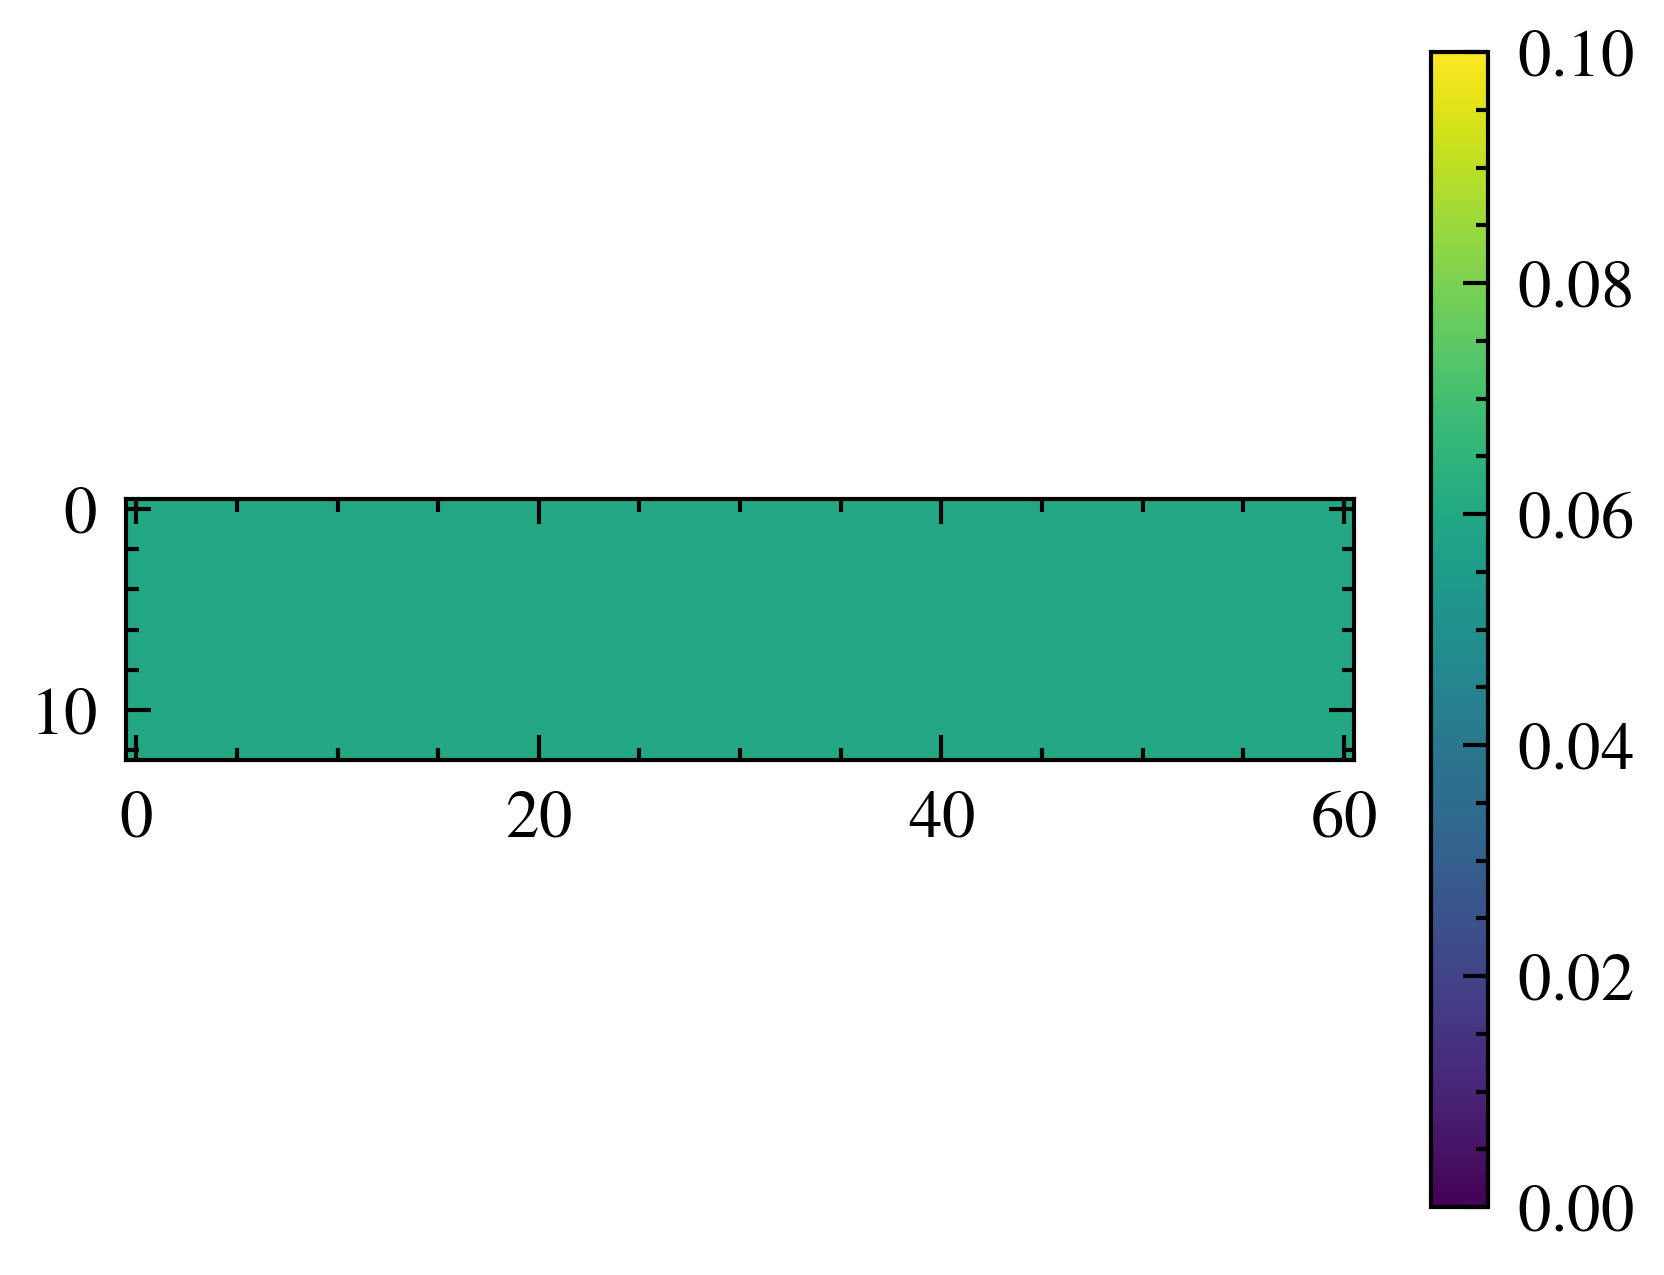

In [135]:
matrix  = abs(results_static[0::5].reshape(793,1))

# 需要删除和插值的索引（这里将索引全部减去 1）
indices_to_remove = [424, 418, 412, 406, 400, 394, 388, 382, 376, 370]
adjusted_indices = [idx - 1 for idx in indices_to_remove]

# 创建一个副本来进行操作
matrix_copy = matrix.copy()

# 将要插值的索引置为NaN，以便后续处理
matrix_copy[adjusted_indices] = np.nan

# 对每个NaN值进行插值处理
for idx in adjusted_indices:
    # 找到前后的两个有效值
    prev_idx = idx - 1
    next_idx = idx + 1
    
    # 找到前一个有效值
    while prev_idx >= 0 and np.isnan(matrix_copy[prev_idx]):
        prev_idx -= 1
    # 找到后一个有效值
    while next_idx < len(matrix_copy) and np.isnan(matrix_copy[next_idx]):
        next_idx += 1
    
    # 检查前后值是否存在
    if prev_idx >= 0 and next_idx < len(matrix_copy):
        # 用前后两个有效值的平均值来填补NaN
        matrix_copy[idx] = (matrix_copy[prev_idx] + matrix_copy[next_idx]) / 2

plt.imshow(matrix_copy.reshape(13,61), vmin=0, vmax=0.1)
plt.colorbar()

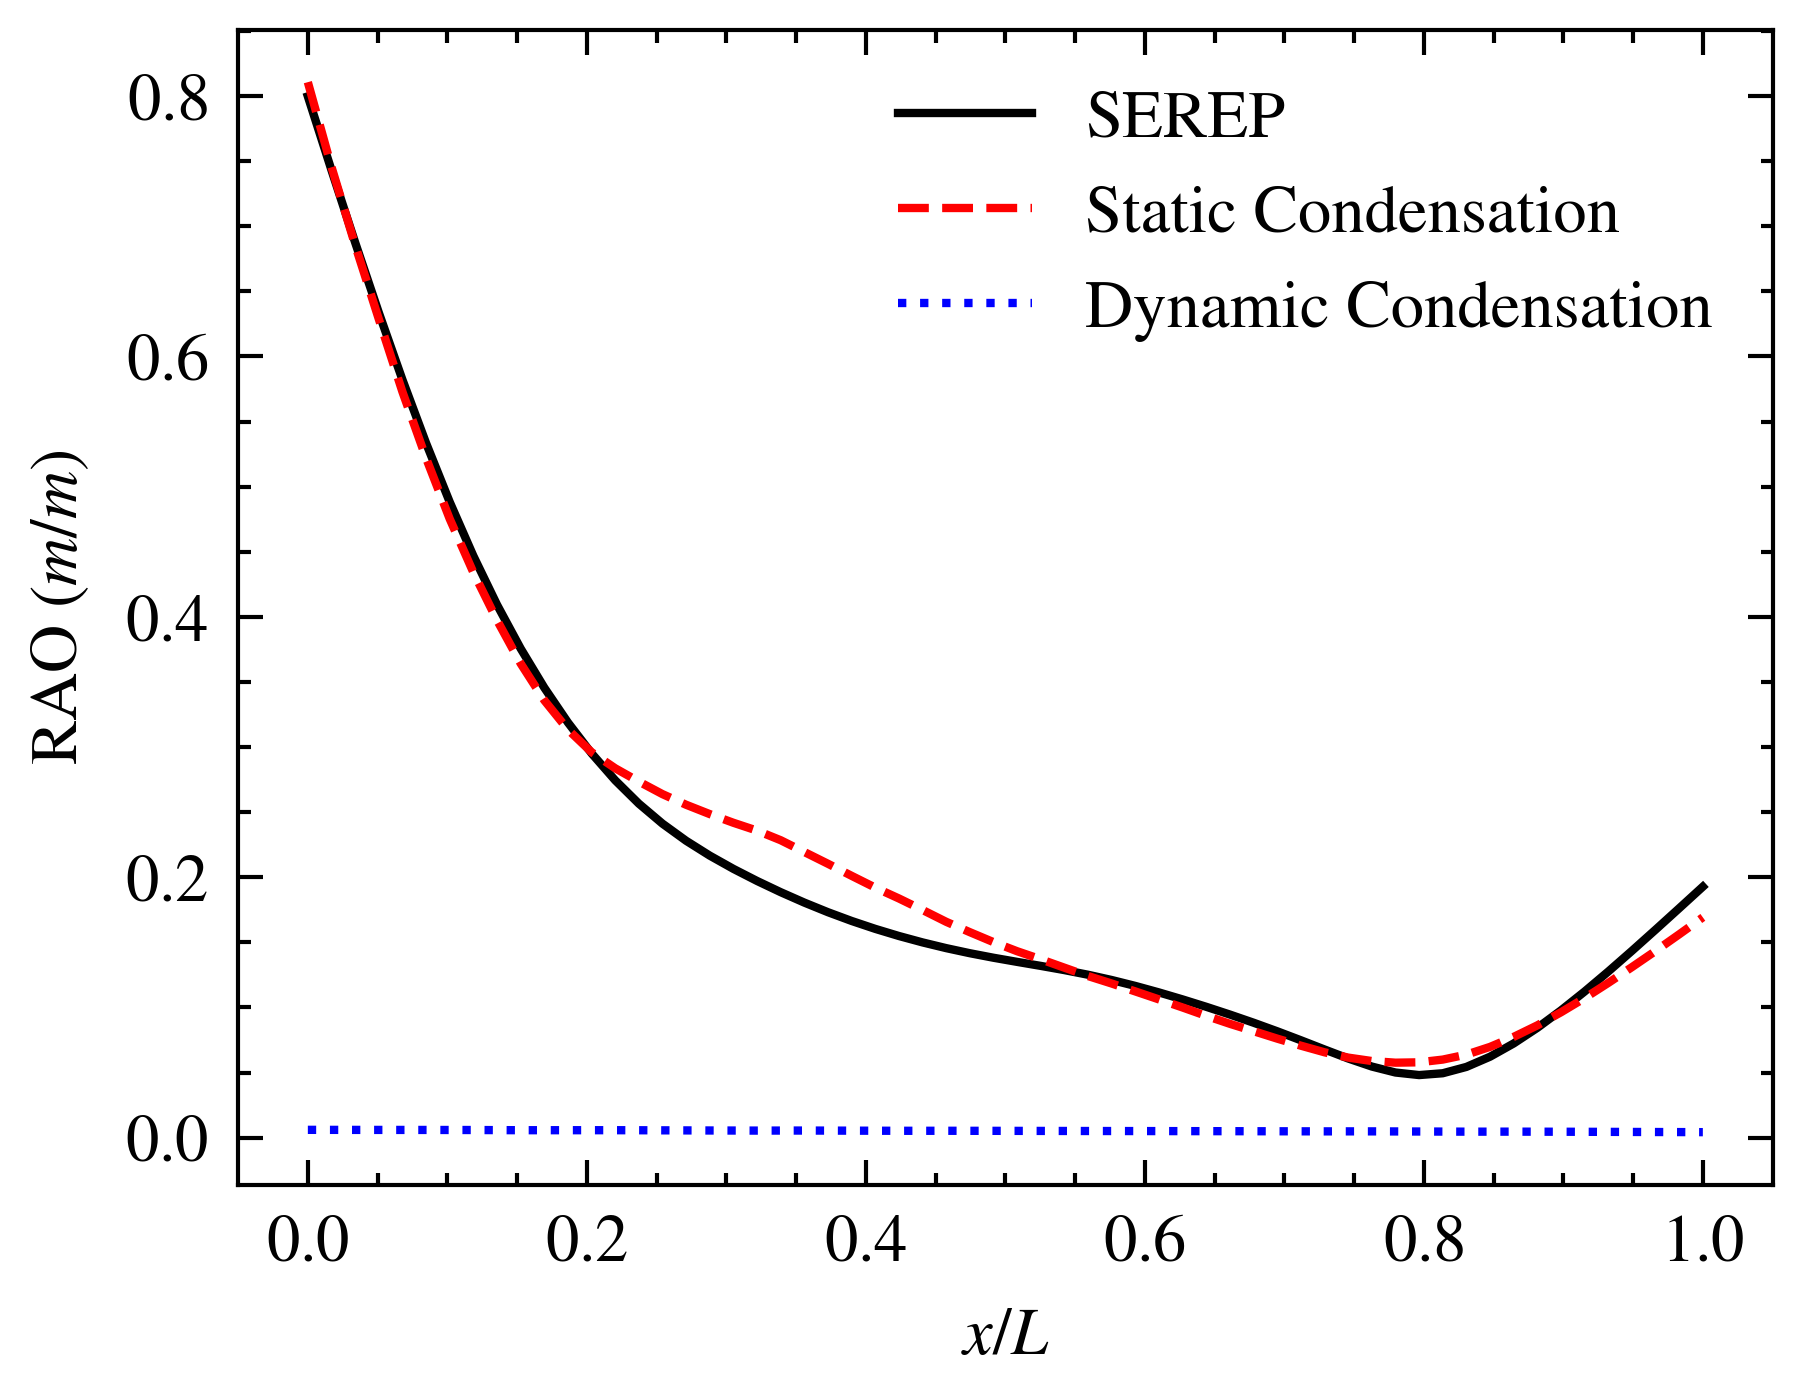

In [136]:
i = 2
# 处理位移结果
mid_static = results_static[367*5-5:427*5-5, :]
heave_static = abs(mid_static[i::5])

mid_dynamic = results_dynamic[367*5-5:427*5-5, :]
heave_dynamic = abs(mid_dynamic[i::5])

mid_serep = result_serep[367*5-5:427*5-5, :]
heave_serep = abs(mid_serep[i::5])

# 处理实验数据
from DM_Verify import process_exp_data
import scienceplots
# x, y = process_exp_data("E:/phd/Code/DM-FEM2D/data/Experiment_300_60/exp_300.txt")
# y = np.array(y)

# 绘图
x1 = np.linspace(0, 1, 60)
plt.style.use(['science', 'no-latex', 'ieee'])
plt.plot(x1, heave_serep, label="SEREP")
plt.plot(x1, heave_static[::-1], label="Static Condensation")
plt.plot(x1, heave_dynamic[::-1], label="Dynamic Condensation")
# plt.scatter(x, y, color='black', label="Model test", s=10)
plt.legend()
# plt.ylim(0, 0.1)  # 调整y轴坐标
plt.xlabel(r'$x/L$')
plt.ylabel(r'RAO ($m/m$)')
plt.show()

### 3.处理静态凝聚和动态凝聚出现棋盘格问题
### 3.1 修改网格数观察变化